In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# Exploratary data Analiysis
df = pd.read_csv("algerian.csv",skiprows=1)

In [5]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [ ]:
df = df.drop([123, 122, 167])
df.iloc[123]

day                     02
month                   06
year                  2012
Temperature             30
 RH                     73
 Ws                     13
Rain                     4
FFMC                  55.7
DMC                    2.7
DC                     7.8
ISI                    0.6
BUI                    2.9
FWI                    0.2
Classes        not fire   
Name: 125, dtype: str

In [7]:
df.columns =  [col.strip() for col in df.columns ]

In [8]:
df.columns =  [col.capitalize() for col in df.columns]

In [9]:
df = df.reset_index(drop=True)

In [10]:
df.loc[:167,"Region"]=0
df.loc[167:,"Region"]=1

In [11]:
df.iloc[:15]

,Day,Month,Year,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Fwi,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
5,06,06,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire,0.0
6,07,06,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0.0
7,08,06,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0.0
8,09,06,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0.0
9,10,06,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0.0


In [12]:
df[["Day","Month","Year","Temperature", "Rh", "Ws"]] = df[["Day","Month","Year","Temperature", "Rh", "Ws"]].astype(int)

In [13]:
df[["Rh","Ws","Rain","Ffmc", "Dmc", "Dc", "Isi", "Bui", "Fwi"]] = df[["Rh","Ws","Rain","Ffmc", "Dmc", "Dc", "Isi", "Bui", "Fwi"]].astype(float)

In [14]:
def checkisFire(x):
    if "not fire" in x:
        return 0
    return 1
df["is_fire"] = df["Classes"].apply(checkisFire)

In [15]:
df = df.drop("Classes", axis=1)

In [16]:
 df = df.drop(["Day", "Month", "Year"], axis=1)

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Rh'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'Ffmc'}>,
        <Axes: title={'center': 'Dmc'}>],
       [<Axes: title={'center': 'Dc'}>, <Axes: title={'center': 'Isi'}>,
        <Axes: title={'center': 'Bui'}>],
       [<Axes: title={'center': 'Fwi'}>,
        <Axes: title={'center': 'Region'}>,
        <Axes: title={'center': 'is_fire'}>]], dtype=object)

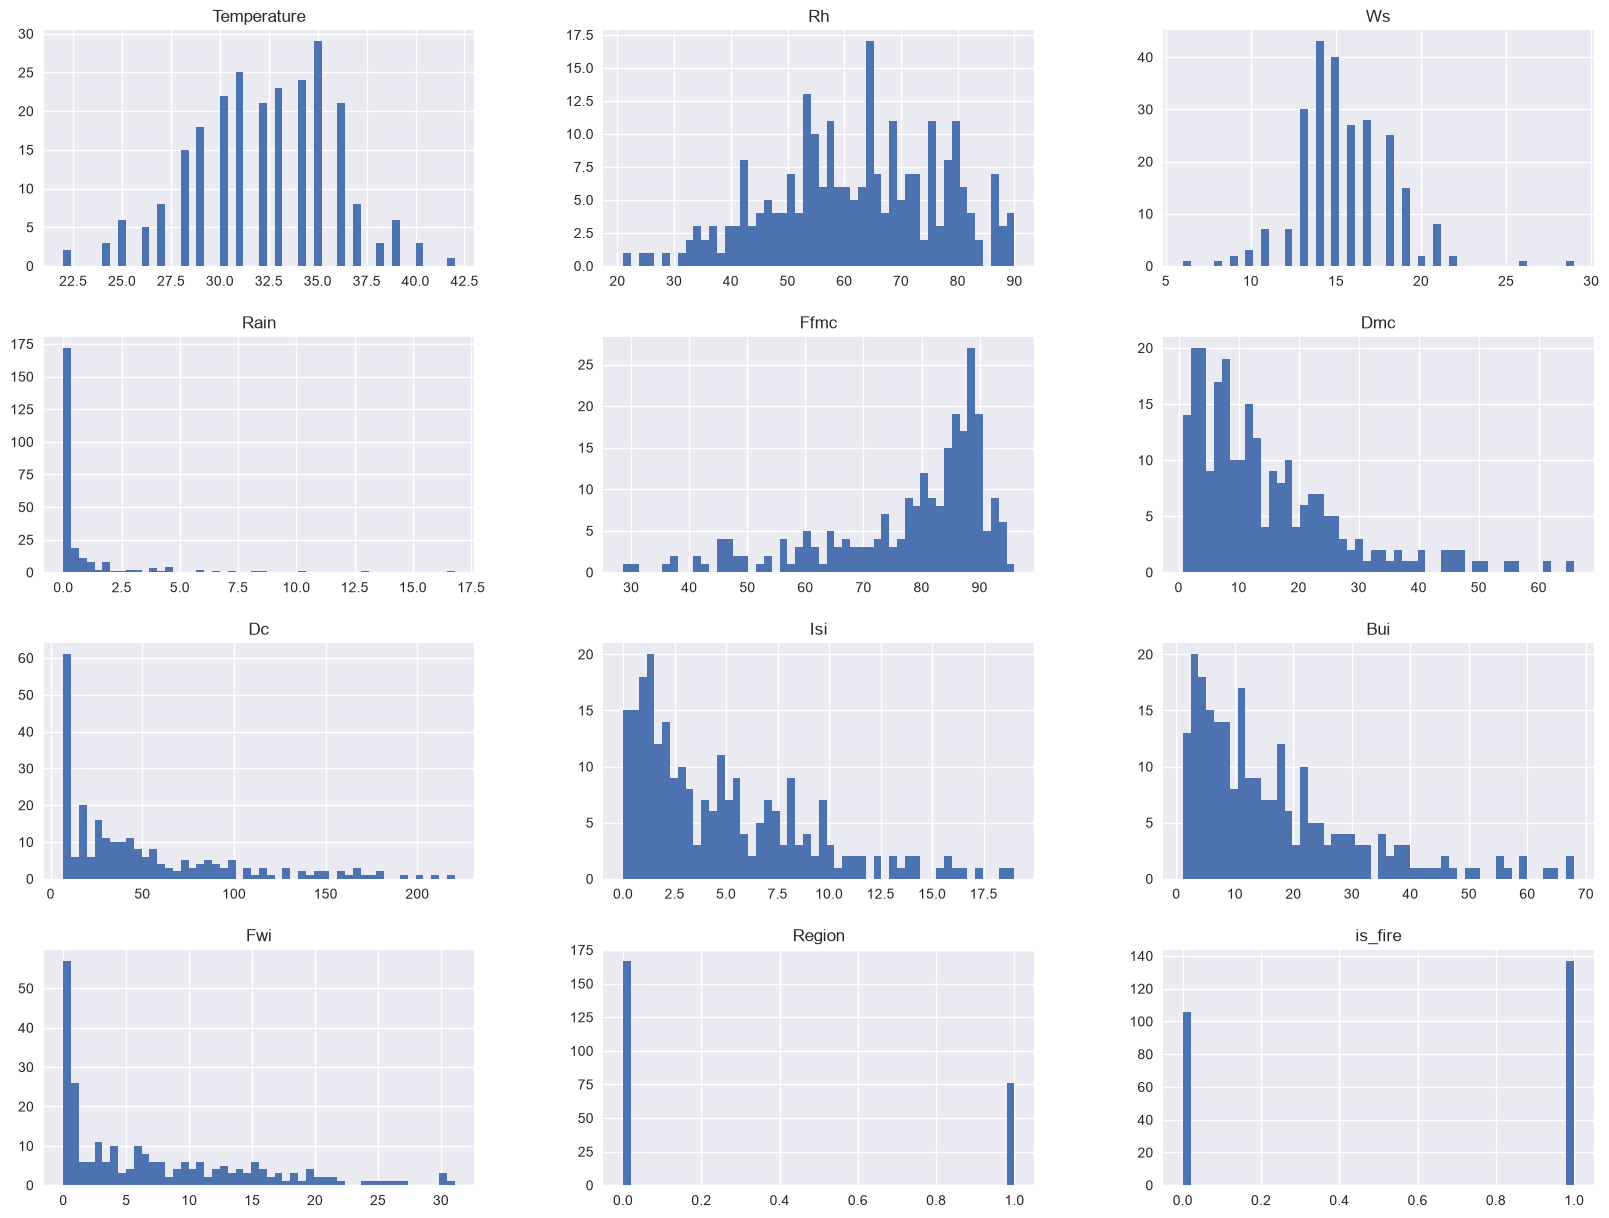

In [17]:
## Visualiasation
plt.style.use('seaborn-v0_8')
df.hist(bins=50, figsize=(20,15))

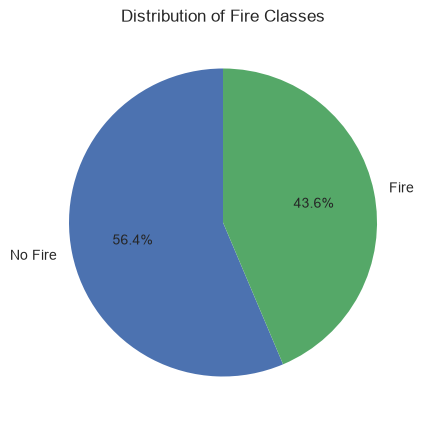

In [18]:
x = df["is_fire"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(
    x,
    labels=["No Fire", "Fire"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Fire Classes")
plt.show()

In [19]:
df.corr()

,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Fwi,Region,is_fire
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.236408,0.516015
Rh,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.300602,-0.432161
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.159870,-0.069964
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.122928,-0.379097
Ffmc,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.245635,0.769492
Dmc,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.344195,0.585658
Dc,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.163925,0.511123
Isi,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.341676,0.735197
Bui,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.272633,0.586639
Fwi,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.330668,0.719216


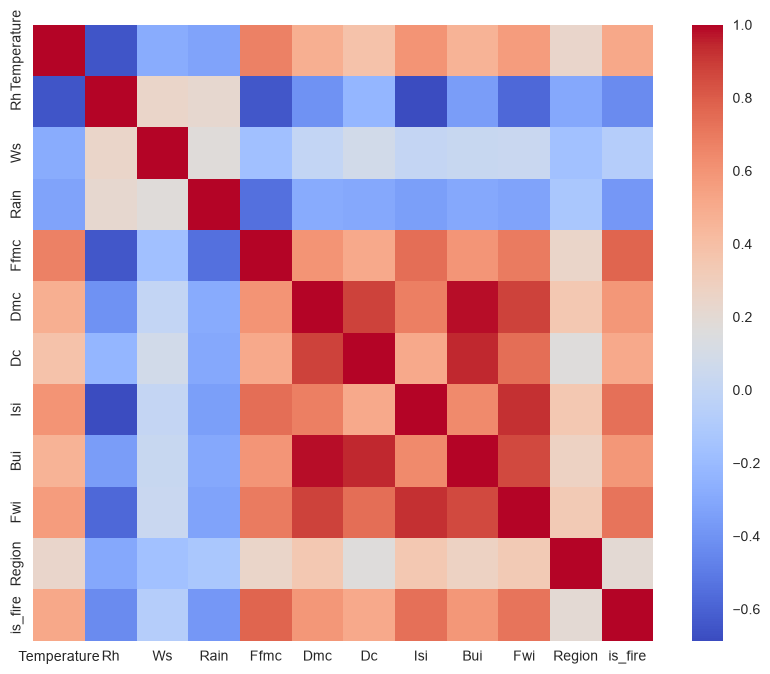

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [21]:
def highcorrelationfinder(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_corr.add(corr_matrix.columns[i])

    return col_corr

In [22]:
col_to_be_removed = highcorrelationfinder(df, 0.80)
col_to_be_removed.remove("Fwi")
col_to_be_removed

{'Bui', 'Dc'}

In [23]:
df = df.drop(col_to_be_removed, axis=1)

In [24]:
df

,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Isi,Fwi,Region,is_fire
0,29,57.0,18.0,0.0,65.7,3.4,1.3,0.5,0.0,0
1,29,61.0,13.0,1.3,64.4,4.1,1.0,0.4,0.0,0
2,26,82.0,22.0,13.1,47.1,2.5,0.3,0.1,0.0,0
3,25,89.0,13.0,2.5,28.6,1.3,0.0,0.0,0.0,0
4,27,77.0,16.0,0.0,64.8,3.0,1.2,0.5,0.0,0
...,...,...,...,...,...,...,...,...,...,...
238,30,65.0,14.0,0.0,85.4,16.0,4.5,6.5,1.0,1
239,28,87.0,15.0,4.4,41.1,6.5,0.1,0.0,1.0,0
240,27,87.0,29.0,0.5,45.9,3.5,0.4,0.2,1.0,0
241,24,54.0,18.0,0.1,79.7,4.3,1.7,0.7,1.0,0


<Axes: >

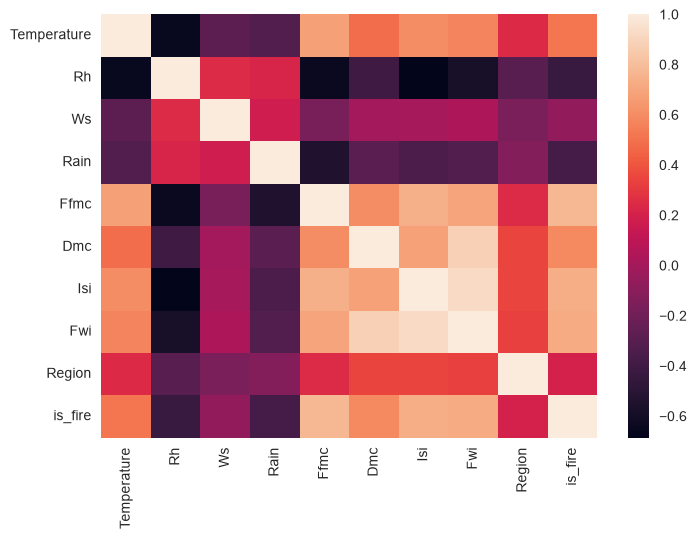

In [25]:
sns.heatmap(df.corr())

In [26]:
## model training
!pip install -U scikit-learn

In [27]:
y = df["Fwi"]
X = df[[col for col in df.columns if col!="Fwi"]]

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

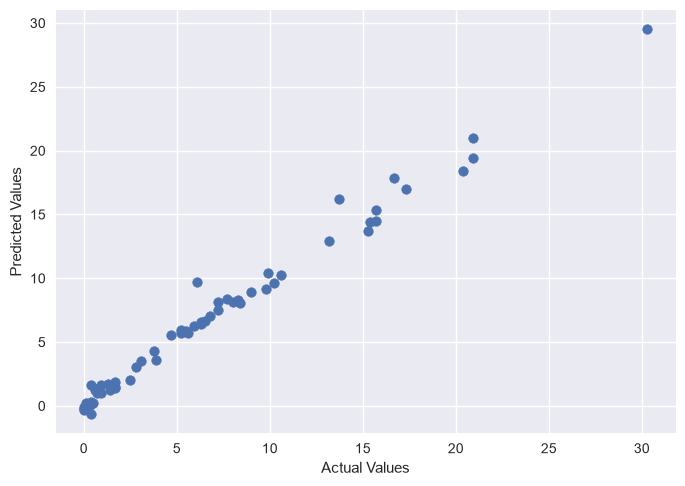

Mean Absolute Error: 0.571940708267456
R² Score: 0.9839140811741253


In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

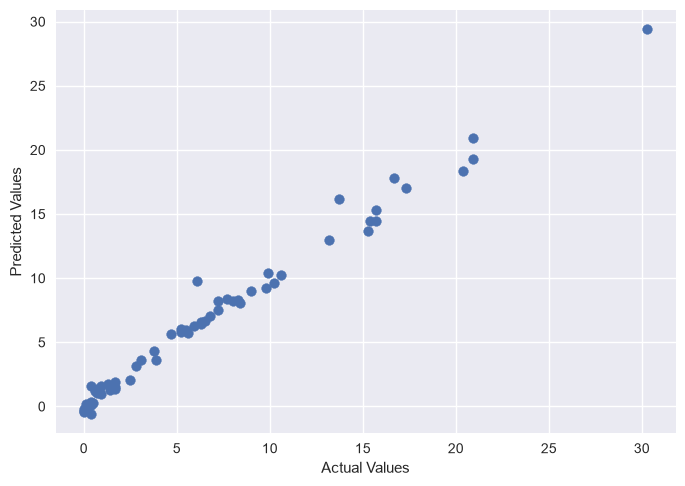

Mean Absolute Error: 0.5879914272170845
R² Score: 0.9833152699477429


In [30]:
from sklearn.linear_model import Ridge
modelr = Ridge()
modelr.fit(X_train, y_train)
y_pred = modelr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

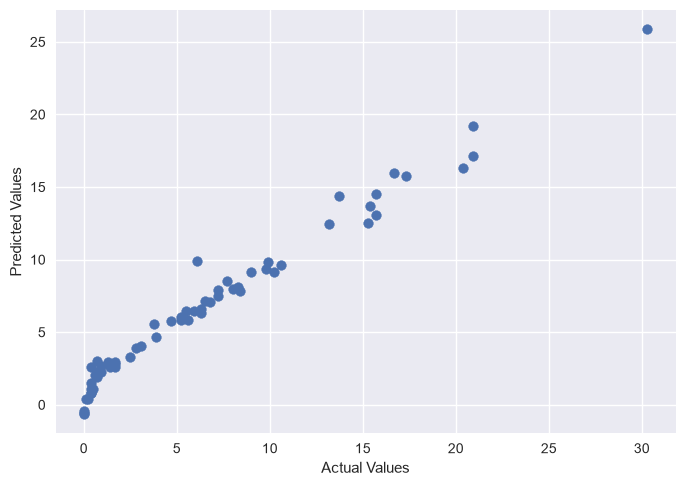

Mean Absolute Error: 1.1331759949144087
R² Score: 0.9492020263112388


In [31]:
from sklearn.linear_model import Lasso
modelr = Lasso()
modelr.fit(X_train, y_train)
y_pred = modelr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

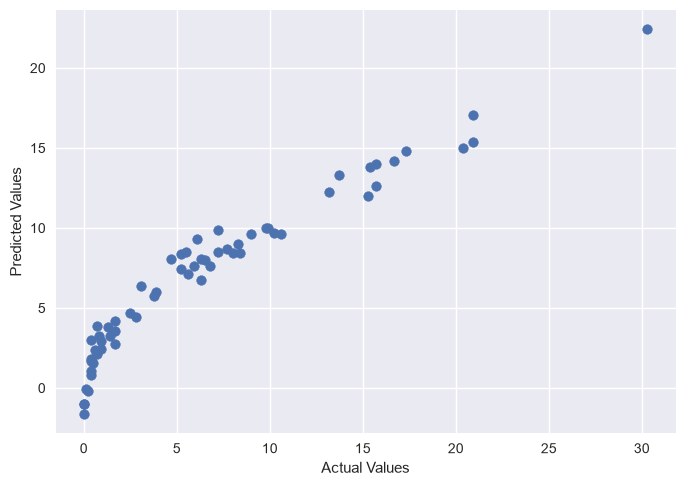

Mean Absolute Error: 1.8825615096287431
R² Score: 0.8752010657073627


In [32]:
from sklearn.linear_model import ElasticNet
modelr = ElasticNet()
modelr.fit(X_train, y_train)
y_pred = modelr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Best Alpha: 1.0


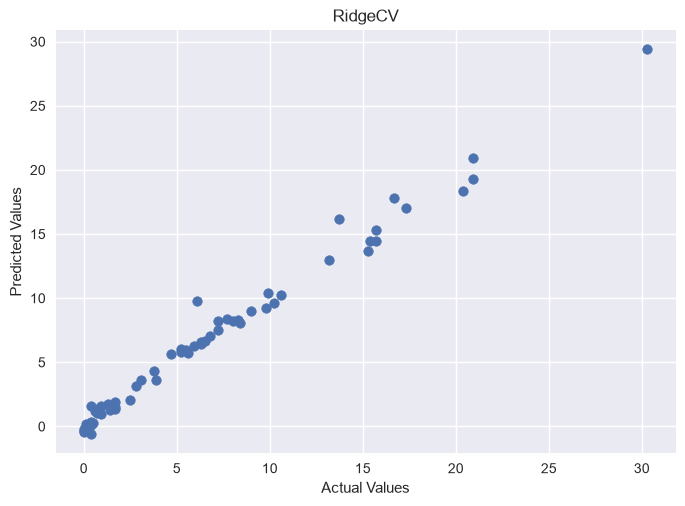

Mean Absolute Error: 0.5879914272170845
R² Score: 0.9833152699477429


In [34]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Ridge with Cross Validation
modelr = RidgeCV(cv=5)
modelr.fit(X_train, y_train)

# Best alpha chosen by cross-validation
print("Best Alpha:", modelr.alpha_)

# Predictions
y_pred = modelr.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("RidgeCV")
plt.show()

print("Mean Absolute Error:", mae)
print("R² Score:", r2)